# 02 — HC60 feature analysis + SHAP

Графики **inline** (`%matplotlib inline`) и при необходимости сохранение в `v2/outputs/figures/hc60_v2/`.

Требует предварительно собранный `core_hc60_v2.parquet` (ноутбук `01_core_handcrafted_features_v2.ipynb`).

In [1]:
%matplotlib inline
from __future__ import annotations
import json
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

def resolve_v2() -> Path:
    cur = Path.cwd().resolve()
    for p in [cur, *cur.parents]:
        if (p / "v2" / "pyproject.toml").is_file():
            return p / "v2"
        if p.name == "v2" and (p / "pyproject.toml").is_file():
            return p
    raise FileNotFoundError("v2/pyproject.toml")

BASE = resolve_v2()
sys.path.insert(0, str(BASE))
FIG = BASE / "outputs" / "figures" / "hc60_v2"
TAB = BASE / "outputs" / "tables" / "hc60_v2"
for d in (FIG, TAB):
    d.mkdir(parents=True, exist_ok=True)

from src.core_hc60_features import HC60_FEATURE_NAMES

PQ = BASE / "data" / "interim" / "features" / "core_hc60_v2.parquet"
df = pd.read_parquet(PQ)
feat_cols = list(HC60_FEATURE_NAMES)
print(df.shape, "features", len(feat_cols))


(23827, 73) features 60


In [2]:
# A. Data overview
vc = df.groupby(["core_eval_slice", "label"]).size().unstack(fill_value=0)
try:
    from IPython.display import display
    display(vc)
except Exception:
    print(vc)
pd.crosstab([df["scenario_family"], df["core_eval_slice"]], df["label"]).to_csv(TAB / "scenario_slice_label.csv")
pd.crosstab([df["channel"], df["core_eval_slice"]], df["label"]).to_csv(TAB / "channel_slice_label.csv")
print("saved crosstabs to", TAB)


label,0,1
core_eval_slice,,
test_claude_binary,1846,1846
test_claude_holdout,0,2059
test_seen,908,908
train,6777,6777
val,1353,1353


saved crosstabs to /Users/askar/projects/antifraud-deepfake-detection/v2/outputs/tables/hc60_v2


In [3]:
# B. Top discriminative (train human vs seen_llm) Mann–Whitney + Bonferroni
from scipy.stats import mannwhitneyu
train = df[(df["split"] == "train") & (df["label"].isin([0, 1]))]
h = train[train["label"] == 0]
l = train[train["label"] == 1]
rows = []
for c in feat_cols:
    a, b = h[c].astype(float).values, l[c].astype(float).values
    stat, p = mannwhitneyu(a, b, alternative="two-sided")
    pooled = np.concatenate([a, b])
    m, s = pooled.mean(), pooled.std(ddof=0) or 1.0
    d = (a.mean() - b.mean()) / s
    rows.append({"feature": c, "p_mw": p, "cohen_d_human_minus_llm": d, "n0": len(a), "n1": len(b)})
res = pd.DataFrame(rows)
res["p_bonf"] = (res["p_mw"] * len(res)).clip(upper=1.0)
res = res.sort_values("p_mw")
res.to_csv(TAB / "mannwhitney_train_human_vs_seenllm.csv", index=False)
top = res.head(12)["feature"].tolist()
print("top features", top)


top features ['hc60_smog_index', 'hc60_dash_ratio', 'hc60_colon_ratio', 'hc60_numeral_token_ratio', 'hc60_flesch_kincaid_grade', 'hc60_digit_ratio', 'hc60_chars_per_word', 'hc60_coleman_liau_index', 'hc60_adverb_like_ratio', 'hc60_lexical_burstiness', 'hc60_modal_ratio', 'hc60_std_sentence_len_words']


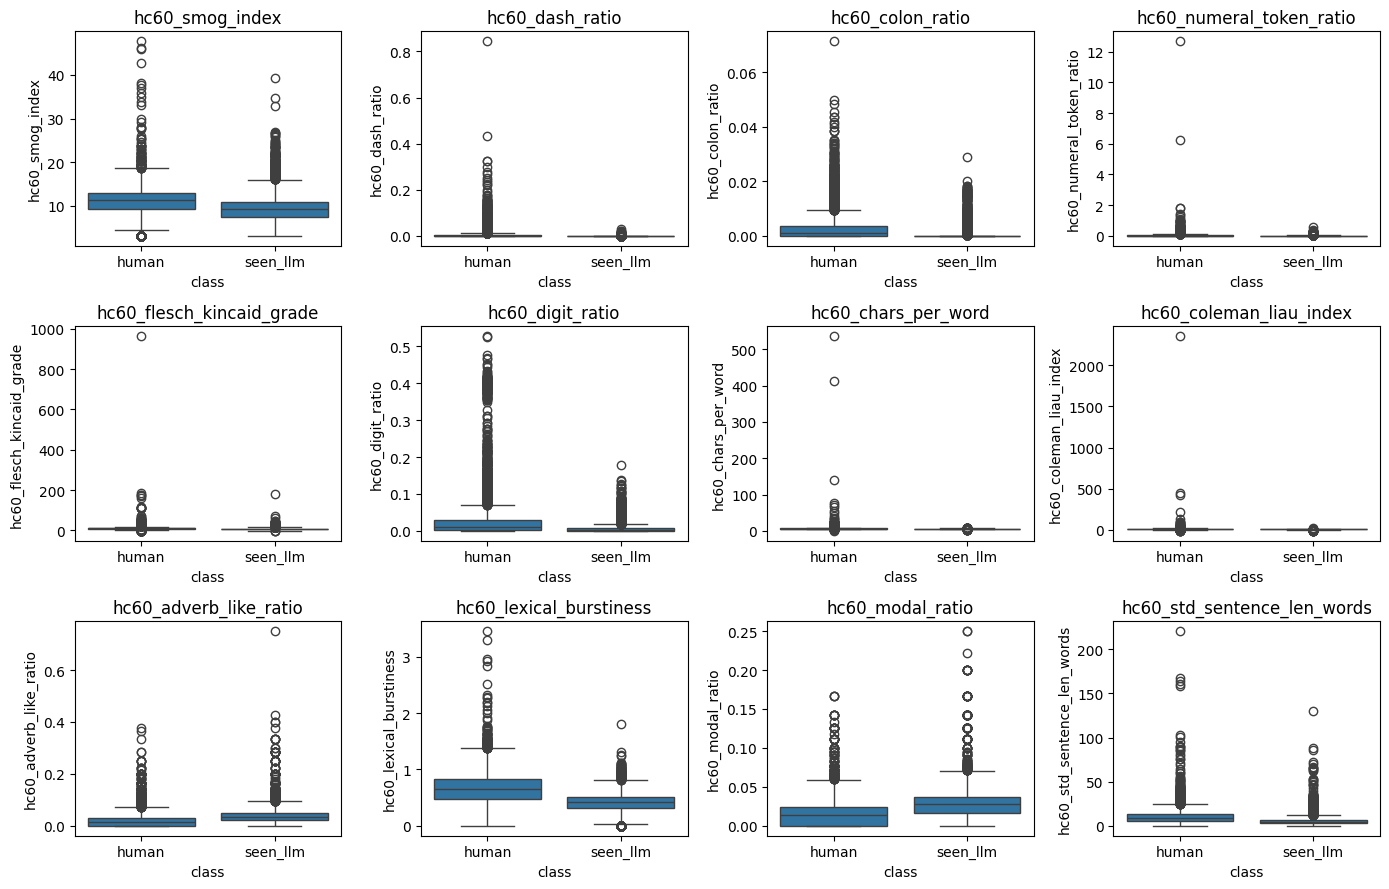

In [4]:
# Boxplots top features: train human vs seen_llm
train_m = df[df["split"] == "train"]
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
axes = axes.ravel()
for ax, c in zip(axes, top):
    sub = train_m[["label", c]].copy()
    sub["class"] = np.where(sub["label"] == 0, "human", "seen_llm")
    sns.boxplot(data=sub, x="class", y=c, ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()
fig.savefig(FIG / "box_top12_train_human_vs_seenllm.png", dpi=150, bbox_inches="tight")


In [5]:
# Drift: test_seen vs test_claude_binary (same feature cols)
from scipy.stats import mannwhitneyu
A = df[df["core_eval_slice"] == "test_seen"]
B = df[df["core_eval_slice"] == "test_claude_binary"]
drift = []
for c in feat_cols:
    a, b = A[c].astype(float).values, B[c].astype(float).values
    if len(a) < 5 or len(b) < 5:
        continue
    _, p = mannwhitneyu(a, b, alternative="two-sided")
    drift.append({"feature": c, "p_mw": p, "median_seen": np.median(a), "median_claude_bin": np.median(b)})
dr = pd.DataFrame(drift).sort_values("p_mw")
dr.to_csv(TAB / "drift_test_seen_vs_test_claude_binary.csv", index=False)
print(dr.head(8))


                        feature           p_mw  median_seen  median_claude_bin
56          hc60_stopword_ratio  3.184178e-161     0.476190           0.384615
8         hc60_short_word_ratio  4.608480e-124     0.410026           0.333333
35  hc60_avg_token_length_chars  8.871095e-119     4.500000           4.926186
5       hc60_avg_word_len_chars  8.871095e-119     4.500000           4.926186
9           hc60_chars_per_word  1.986483e-106     5.857864           6.357404
7          hc60_long_word_ratio   1.995411e-99     0.210526           0.269231
54      hc60_coleman_liau_index   1.454445e-97     8.572188          11.015423
12        hc60_whitespace_ratio   1.477695e-96     0.176374           0.161699


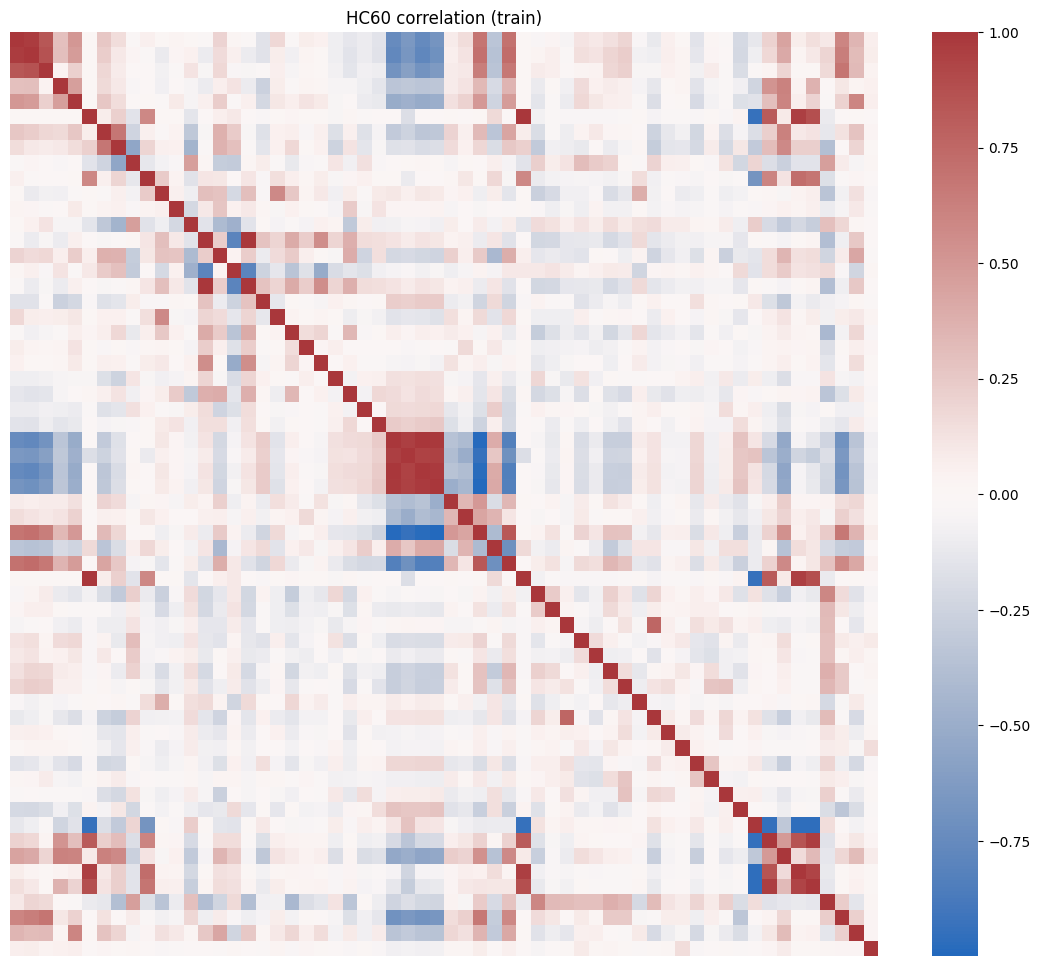

In [6]:
# Correlation heatmap (train)
cm = train[feat_cols].corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, cmap="vlag", center=0, ax=ax, xticklabels=False, yticklabels=False)
ax.set_title("HC60 correlation (train)")
plt.show()
fig.savefig(FIG / "corr_heatmap_train.png", dpi=150, bbox_inches="tight")


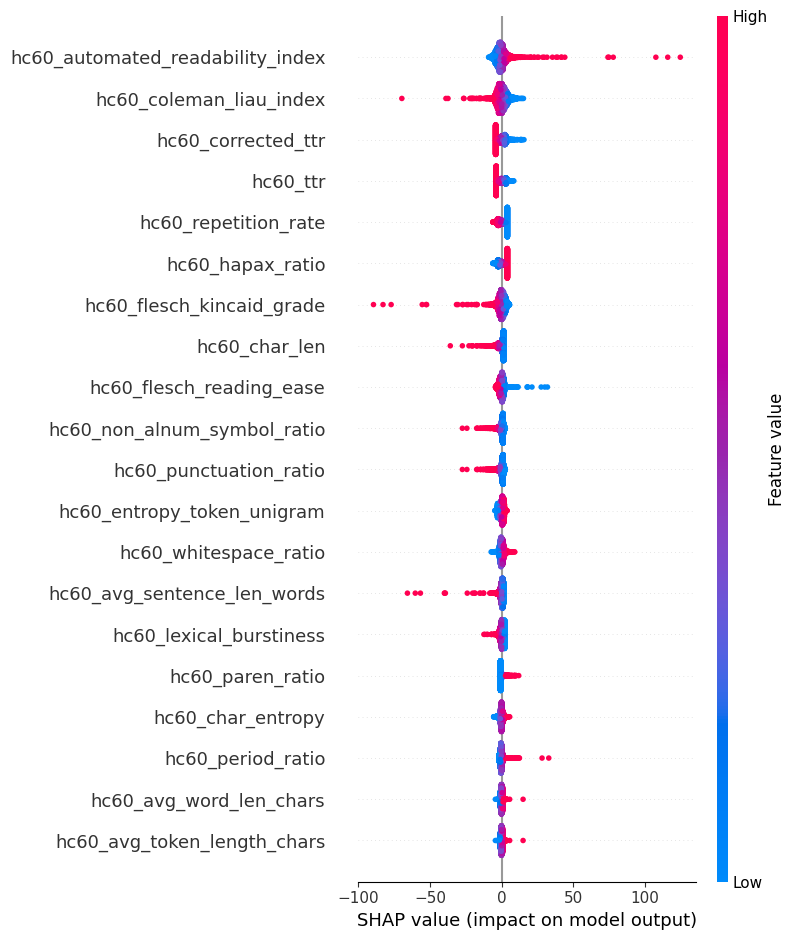

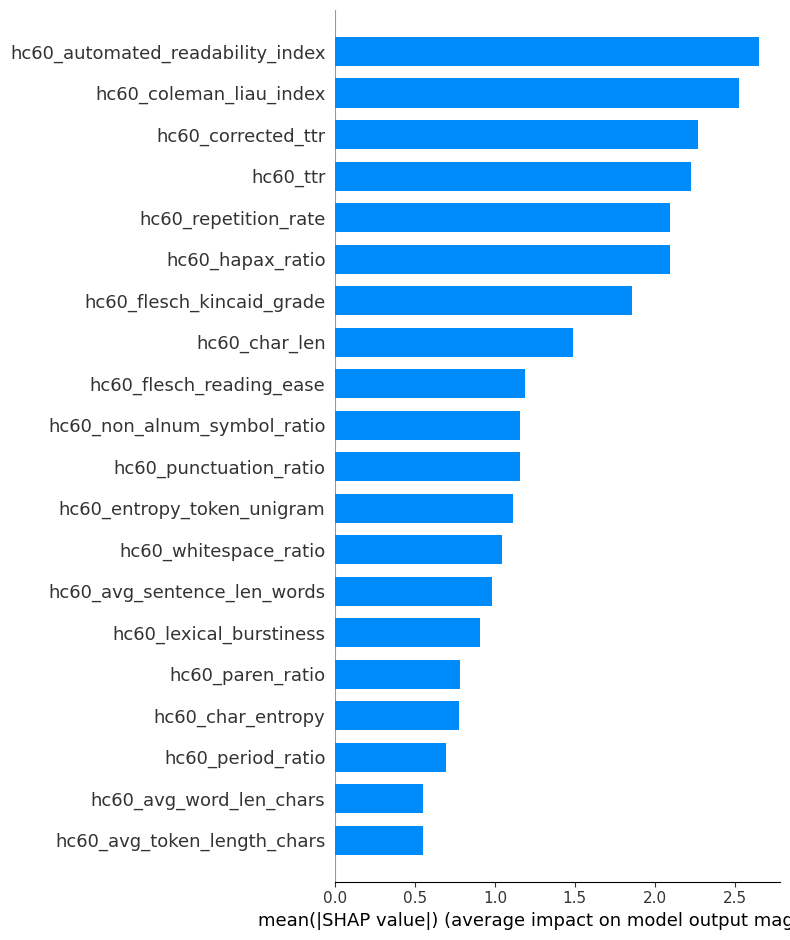

<Figure size 640x480 with 0 Axes>

In [7]:
# E. SHAP — best linear model on train subset (speed)
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sub_n = min(4000, len(train))
tr = train.sample(sub_n, random_state=42)
X = tr[feat_cols].astype(np.float64).values
y = tr["label"].astype(int).values
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42)),
])
pipe.fit(X, y)
X_sc = pipe.named_steps["scaler"].transform(X)
lr = pipe.named_steps["lr"]
explainer = shap.LinearExplainer(lr, X_sc)
sv = explainer.shap_values(X_sc)
shap.summary_plot(sv, pipe.named_steps["scaler"].transform(X), feature_names=feat_cols, plot_type="dot", show=True)
plt.savefig(FIG / "shap_beeswarm_linear_train_sub.png", dpi=150, bbox_inches="tight")
shap.summary_plot(sv, pipe.named_steps["scaler"].transform(X), feature_names=feat_cols, plot_type="bar", show=True)
plt.savefig(FIG / "shap_bar_linear_train_sub.png", dpi=150, bbox_inches="tight")


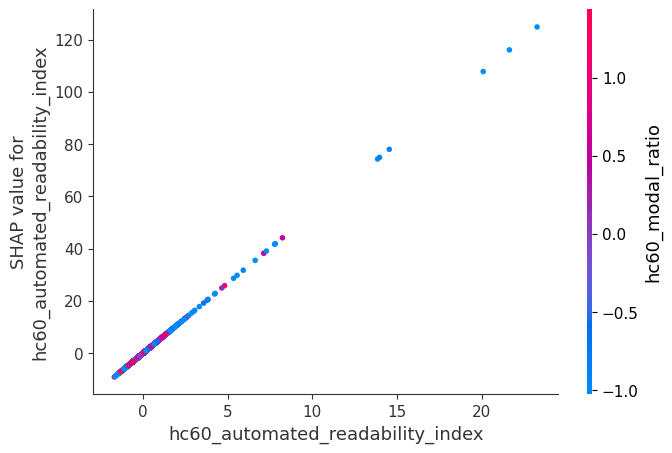

<Figure size 640x480 with 0 Axes>

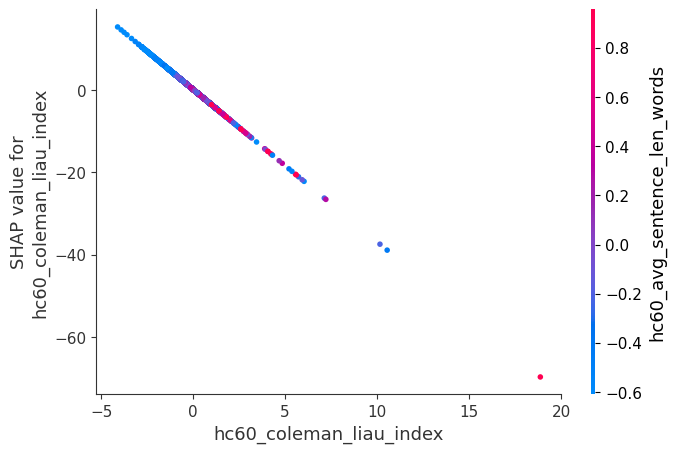

<Figure size 640x480 with 0 Axes>

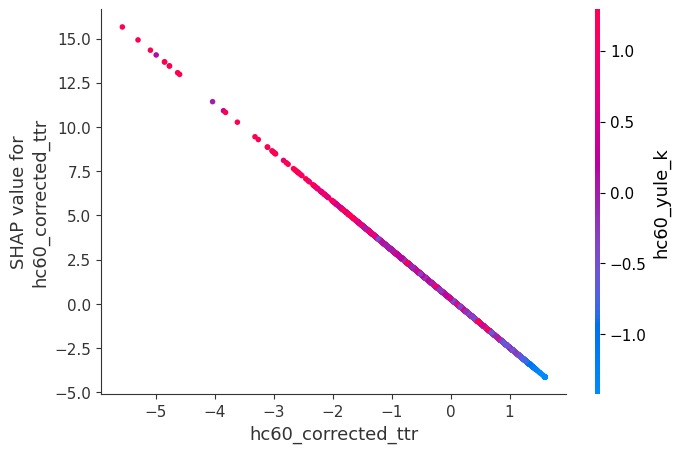

<Figure size 640x480 with 0 Axes>

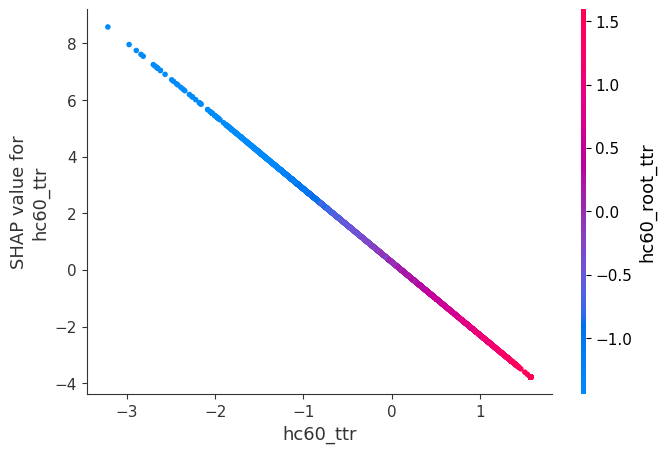

<Figure size 640x480 with 0 Axes>

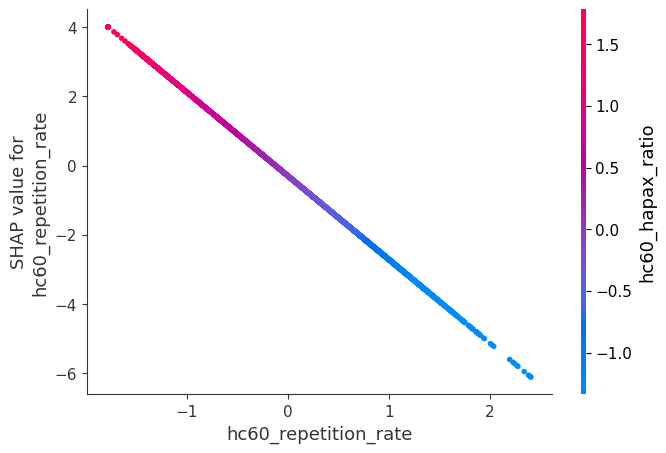

<Figure size 640x480 with 0 Axes>

In [8]:
# Dependence plots for first 5 SHAP-important features (by mean |shap|)
importance = np.abs(sv).mean(axis=0)
order = np.argsort(-importance)[:8]
Xt = pipe.named_steps["scaler"].transform(X)
for j in order[:5]:
    shap.dependence_plot(int(j), sv, Xt, feature_names=feat_cols, show=True)
    plt.savefig(FIG / f"shap_dependence_{feat_cols[int(j)]}.png", dpi=150, bbox_inches="tight")
